### Network Multiagent system

A Network Multi-Agent System (Network MAS) is a system where multiple intelligent agents communicate and cooperate over a network to solve tasks collectively.

In [3]:
from typing_extensions import Literal
from langchain_core.tools import tool
from langchain_groq import ChatGroq
from langgraph.graph import MessagesState, StateGraph,START,END
from langgraph.types import Command
from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.prebuilt import create_react_agent
from typing import Annotated
from langchain_experimental.utilities import PythonREPL

In [4]:

load_dotenv()

True

In [5]:
llm=ChatGroq(model="llama-3.1-8b-instant")

In [6]:
llm.invoke("hii")

AIMessage(content='Hello! How are you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 37, 'total_tokens': 45, 'completion_time': 0.013894596, 'completion_tokens_details': None, 'prompt_time': 0.001732564, 'prompt_tokens_details': None, 'queue_time': 0.052466255, 'total_time': 0.01562716}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e204f-f2e7-73b0-a111-f2da82f65858-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 37, 'output_tokens': 8, 'total_tokens': 45})

In [10]:
@tool
def transfer_to_mutliplication_expert():
    """Ask multiplication agent for help, do not call any other tool besides the given tool"""
    return

In [11]:
@tool
def transfer_to_addition_expert():
    """Ask addition agent for help, do not call any other tool besides the given tool"""
    return

In [12]:
model_with_tool=llm.bind_tools([transfer_to_mutliplication_expert]).invoke("what's (3 + 5) * 12. Provide me the output")

In [13]:
model_with_tool

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '66pyv3ttp', 'function': {'arguments': '{}', 'name': 'transfer_to_mutliplication_expert'}, 'type': 'function'}, {'id': 'pt2pnnaxe', 'function': {'arguments': '{"answer":"true","math":"true","question":"(3 + 5) * 12"}', 'name': 'transfer_to_mutliplication_expert'}, 'type': 'function'}, {'id': 'svt53bj06', 'function': {'arguments': '{"answer":"true","math":"true","question":"how to solve (3 + 5) * 12"}', 'name': 'transfer_to_mutliplication_expert'}, 'type': 'function'}, {'id': '6yw8x2pe5', 'function': {'arguments': '{"answer":"true","math":"true","question":"what is the result of (3 + 5) * 12"}', 'name': 'transfer_to_mutliplication_expert'}, 'type': 'function'}, {'id': 'qns7a5114', 'function': {'arguments': '{"answer":"true","math":"true","question":"the result of (3 + 5) * 12"}', 'name': 'transfer_to_mutliplication_expert'}, 'type': 'function'}, {'id': '05acxg91b', 'function': {'arguments': '{"answer":"true","math":"true","q

In [14]:
model_with_tool.tool_calls

[{'name': 'transfer_to_mutliplication_expert',
  'args': {},
  'id': '66pyv3ttp',
  'type': 'tool_call'},
 {'name': 'transfer_to_mutliplication_expert',
  'args': {'answer': 'true', 'math': 'true', 'question': '(3 + 5) * 12'},
  'id': 'pt2pnnaxe',
  'type': 'tool_call'},
 {'name': 'transfer_to_mutliplication_expert',
  'args': {'answer': 'true',
   'math': 'true',
   'question': 'how to solve (3 + 5) * 12'},
  'id': 'svt53bj06',
  'type': 'tool_call'},
 {'name': 'transfer_to_mutliplication_expert',
  'args': {'answer': 'true',
   'math': 'true',
   'question': 'what is the result of (3 + 5) * 12'},
  'id': '6yw8x2pe5',
  'type': 'tool_call'},
 {'name': 'transfer_to_mutliplication_expert',
  'args': {'answer': 'true',
   'math': 'true',
   'question': 'the result of (3 + 5) * 12'},
  'id': 'qns7a5114',
  'type': 'tool_call'},
 {'name': 'transfer_to_mutliplication_expert',
  'args': {'answer': 'true',
   'math': 'true',
   'question': 'the solution to (3 + 5) * 12'},
  'id': '05acxg91b',

In [34]:
## Addition expert node
def addition_expert(state:MessagesState)->Command[Literal["multiplication_expert","__end__"]]:
    system_prompt = (
        "You are an addition expert, you can ask the multiplication expert for help with multiplication."
        "Always do your portion of calculation before the handoff."
    )
    
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]

    ai_msg=llm.bind_tools([transfer_to_mutliplication_expert]).invoke(messages)

    if len(ai_msg.tool_calls)>0:
        tool_call_id=ai_msg.tool_calls[-1]["id"]
        tool_msg={
            "role":"tool",
            "content":"Successfully transferred",
            "tool_call_id":tool_call_id
        }

        return Command(
            goto="multiplication_expert",
            update={"messages":[ai_msg,tool_msg]}
        )
    
    return {"messages":[ai_msg]}

In [43]:
## Multiplication Expert
def multiplication_expert(state:MessagesState)-> Command[Literal["addition_expert", "__end__"]]:
    
    system_prompt = (
        "You are a multiplication expert, you can ask an addition expert for help with addition. "
        "Always do your portion of calculation before the handoff."
    )
    
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    
    ai_msg = llm.bind_tools([transfer_to_addition_expert]).invoke(messages)
    
    if len(ai_msg.tool_calls) > 0:
        tool_call_id = ai_msg.tool_calls[-1]["id"]
        tool_msg = {
            "role": "tool",
            "content": "Successfully transferred",
            "tool_call_id": tool_call_id,
        }
        return Command(goto="additional_expert", update={"messages": [ai_msg, tool_msg]})
    return {"messages": [ai_msg]}

In [44]:
graph=StateGraph(MessagesState)

In [45]:
graph.add_node("addition_expert",addition_expert)
graph.add_node("multiplication_expert",multiplication_expert)

In [46]:
graph.add_edge(START,"addition_expert")

In [47]:
app=graph.compile()


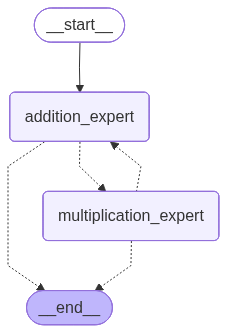

In [48]:
display(Image(app.get_graph().draw_mermaid_png()))

In [49]:
from langchain_core.messages import convert_to_messages
def pretty_print_messages(update):
    if isinstance(update, tuple):
        ns, update = update
        # skip parent graph updates in the printouts
        if len(ns) == 0:
            return

        graph_id = ns[-1].split(":")[0]
        print(f"Update from subgraph {graph_id}:")
        print("\n")

    for node_name, node_update in update.items():
        print(f"Update from node {node_name}:")
        print("\n")

        for m in convert_to_messages(node_update["messages"]):
            m.pretty_print()
        print("\n")

In [51]:
# Let's run the graph with an expression that requires both addition and multiplication:
for chunk in app.stream(
    {"messages": [("user", "what's (3 + 5) * 12. Provide me the output")]},
):
    print("****chunk...****")
    
    pretty_print_messages(chunk)

****chunk...****
Update from node addition_expert:


================================== Ai Message ==================================

To find the result of (3 + 5) * 12, I first need to perform the addition inside the parentheses: 3 + 5 = 8. Then, I'll ask the multiplication expert for help with multiplying 8 by 12.
Tool Calls:
  transfer_to_mutliplication_expert (r8xcc2aa5)
 Call ID: r8xcc2aa5
  Args:
================================= Tool Message =================================

Successfully transferred


****chunk...****
Update from node multiplication_expert:


================================== Ai Message ==================================

To solve the equation (3 + 5) * 12, we need to follow the order of operations (PEMDAS):

1. Evaluate the expression inside the parentheses: 3 + 5 = 8
2. Multiply 8 by 12: 8 * 12 = 96

So the final answer is 96.




In [52]:
## Second example for network multiagent system

In [53]:
@tool
def transfer_to_travel_advisor():
    """Ask travel advisor for help, do not call any other tool beside the given tool"""
    return

@tool
def transfer_to_hotel_advisor():
    """Ask hotel advisor for help, do not call any other tool beside the given tool"""
    return

In [60]:

def travel_advisor(state: MessagesState) -> Command[Literal["hotel_advisor", "__end__"]]:
    system_prompt = (
        "You are a general travel expert that can recommend travel destinations (e.g. countries, cities, etc). "
        "If you need hotel recommendations, ask 'hotel_advisor' for help."
    )
    
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    
    ai_msg = llm.bind_tools([transfer_to_hotel_advisor]).invoke(messages)
    
    if len(ai_msg.tool_calls) > 0:
        tool_call_id = ai_msg.tool_calls[-1]["id"]
        tool_msg = {
            "role": "tool",
            "content": "Successfully transferred",
            "tool_call_id": tool_call_id,
        }
        
        return Command(goto="hotel_advisor", update={"messages": [ai_msg, tool_msg]})
    
    return {"messages": [ai_msg]}

In [61]:
def hotel_advisor(state: MessagesState) -> Command[Literal["travel_advisor", "__end__"]]:
    system_prompt = (
        "You are a hotel expert that can provide hotel recommendations for a given destination. "
        "If you need help picking travel destinations, ask 'travel_advisor' for help."
    )
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    ai_msg = llm.bind_tools([transfer_to_travel_advisor]).invoke(messages)
    if len(ai_msg.tool_calls) > 0:
        tool_call_id = ai_msg.tool_calls[-1]["id"]
        tool_msg = {
            "role": "tool",
            "content": "Successfully transferred",
            "tool_call_id": tool_call_id,
        }
        return Command(goto="travel_advisor", update={"messages": [ai_msg, tool_msg]})
    return {"messages": [ai_msg]}

In [62]:

graph_builder = StateGraph(MessagesState)
graph_builder.add_node("travel_advisor", travel_advisor)
graph_builder.add_node("hotel_advisor", hotel_advisor)

In [63]:
graph_builder.add_edge(START, "travel_advisor")

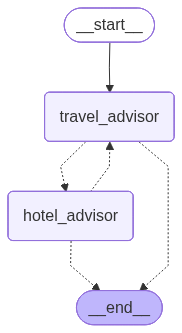

In [64]:
app = graph_builder.compile()
display(Image(app.get_graph().draw_mermaid_png()))

In [68]:
for chunk in app.stream(
    {"messages": [("user", "I am planning a trip to the California in the USA from Mumbai. Can you guide me on travel options and suggest the best hotel?. For your information i have budget of 1 lakh rupees and no preferences")]},
):
    print("****chunk****")
    
    pretty_print_messages(chunk)

****chunk****
Update from node travel_advisor:


================================== Ai Message ==================================
Tool Calls:
  transfer_to_hotel_advisor (dkk52ty2z)
 Call ID: dkk52ty2z
  Args:
================================= Tool Message =================================

Successfully transferred


****chunk****
Update from node hotel_advisor:


================================== Ai Message ==================================

Based on your budget of 1 lakh rupees and no preferences, I would recommend the following hotel options in California:

1. **The Fairmont San Francisco**: This luxurious hotel offers stunning views of the city and the Bay Bridge. It's located in the heart of San Francisco, within walking distance to many popular attractions.

2. **The Ritz-Carlton, Half Moon Bay**: This 5-star resort is situated on a bluff overlooking the Pacific Ocean. It offers stunning ocean views, a world-class spa, and an 18-hole golf course.

3. **The Montage Laguna Beach*